Dataset Preview:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Training Data Shape: (16512, 1)
Testing Data Shape: (4128, 1)

Model Coefficients (Weight): 0.4193384939381274
Intercept (Bias): 0.44459729169078677

Sample Predictions vs Actual:
Predicted: 1.15, Actual: 0.48
Predicted: 1.51, Actual: 0.46
Predicted: 1.90, Actual: 5.00
Predicted: 2.85, Actual: 2.19
Predicted: 2.01, Actual: 2.78

Evaluation Metrics:
MAE : 0.629908653009376
MSE : 0.709

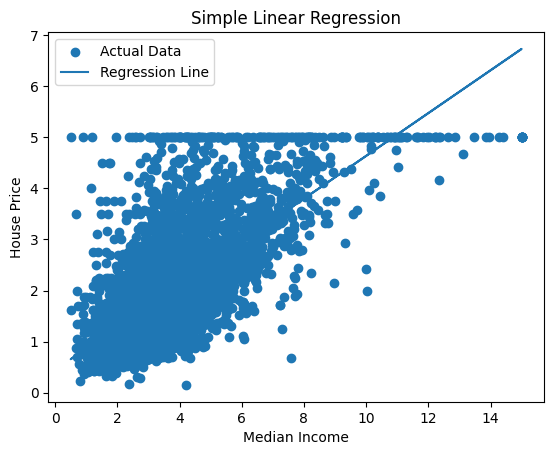


Model might be slightly overfitting.


In [4]:

# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==============================
# 2. Load Dataset
# ==============================
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset Preview:\n", df.head())


# ==============================
# 3. Define Features and Target (SIMPLE LINEAR)
# ==============================
X = df[['MedInc']]   # ✅ Only ONE feature
y = df['target']


# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ==============================
# 5. Train Model
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)


# ==============================
# 6. Model Coefficients
# ==============================
print("\nModel Coefficients (Weight):", model.coef_[0])
print("Intercept (Bias):", model.intercept_)


# ==============================
# 7. Predictions
# ==============================
y_pred = model.predict(X_test)

print("\nSample Predictions vs Actual:")
for i in range(5):
    print(f"Predicted: {y_pred[i]:.2f}, Actual: {y_test.iloc[i]:.2f}")


# ==============================
# 8. Evaluation Metrics
# ==============================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


# ==============================
# 9. Overfitting Check
# ==============================
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("\nModel Performance:")
print("Training Score:", train_score)
print("Testing Score :", test_score)


# ==============================
# 10. Visualization (VERY IMPORTANT)
# ==============================
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_test, y_pred, label="Regression Line")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


# ==============================
# 11. Final Interpretation
# ==============================
if train_score > test_score:
    print("\nModel might be slightly overfitting.")
elif train_score < test_score:
    print("\nModel might be underfitting.")
else:
    print("\nModel is well balanced.")